In [20]:
# import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, precision_score, recall_score, accuracy_score, f1_score , confusion_matrix, classification_report
from xgboost import XGBRegressor, XGBClassifier
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')






In [6]:
df = sns.load_dataset('diamonds')

In [10]:
X = df.drop('cut', axis=1)
y = df['cut']

# encode the input variables
le = LabelEncoder()
X['color'] = le.fit_transform(X['color'])
X['clarity'] = le.fit_transform(X['clarity'])


y = le.fit_transform(y)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

accuracy_score:  0.71440489432703
precision_score:  0.7170058280302155
recall_score:  0.7233265518754871
f1_score:  0.7200228842413444
confusion_matrix: 
 [[ 287   34    3    5    6]
 [  31  696   22   32  223]
 [   4   32 3402  342  512]
 [   4   61  322 2028  360]
 [  10  246  480  352 1294]]
classification_report: 
               precision    recall  f1-score   support

           0       0.85      0.86      0.86       335
           1       0.65      0.69      0.67      1004
           2       0.80      0.79      0.80      4292
           3       0.74      0.73      0.73      2775
           4       0.54      0.54      0.54      2382

    accuracy                           0.71     10788
   macro avg       0.72      0.72      0.72     10788
weighted avg       0.72      0.71      0.71     10788



Text(95.72222222222221, 0.5, 'Actual')

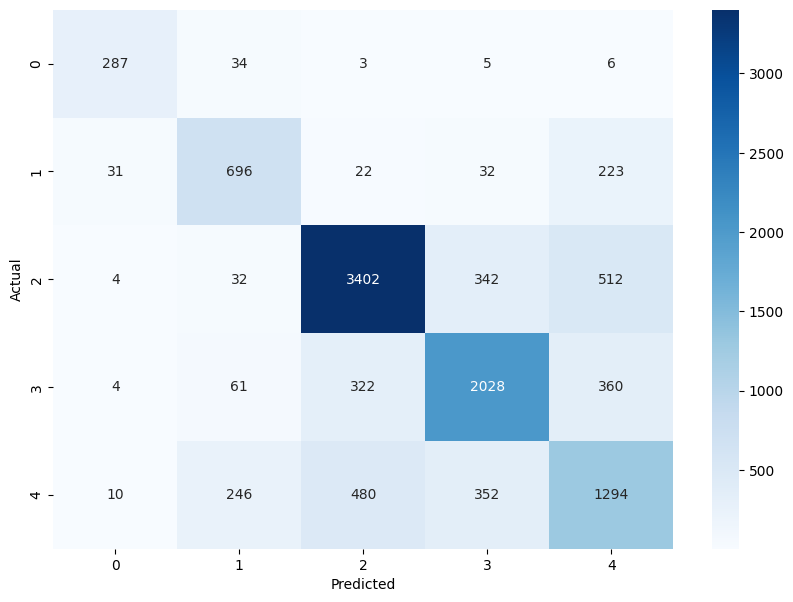

In [15]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
print('accuracy_score: ', accuracy_score(y_test, y_pred))
print('precision_score: ', precision_score(y_test, y_pred, average='macro'))
print('recall_score: ', recall_score(y_test, y_pred, average='macro'))
print('f1_score: ', f1_score(y_test, y_pred, average='macro'))
print("confusion_matrix: \n", confusion_matrix(y_test, y_pred))
print("classification_report: \n", classification_report(y_test, y_pred))
# The metrics for classifiers typically include:
# - accuracy_score: proportion of correct predictions
# - precision_score: proportion of positive identifications that were actually correct
# - recall_score: proportion of actual positives that were identified correctly
# - f1_score: harmonic mean of precision and recall


import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

accuracy_score:  0.78559510567297
confusion_matrix: 
 [[ 303   19    3    7    3]
 [  24  712   18   36  214]
 [   2   13 3928  164  185]
 [   1   14  312 2242  206]
 [   4  156  494  438 1290]]
precision_score:  0.7937008739919553
recall_score:  0.7756643304900416
f1_score:  0.7822747671424806
classification_report: 
               precision    recall  f1-score   support

           0       0.91      0.90      0.91       335
           1       0.78      0.71      0.74      1004
           2       0.83      0.92      0.87      4292
           3       0.78      0.81      0.79      2775
           4       0.68      0.54      0.60      2382

    accuracy                           0.79     10788
   macro avg       0.79      0.78      0.78     10788
weighted avg       0.78      0.79      0.78     10788



Text(95.72222222222221, 0.5, 'Actual')

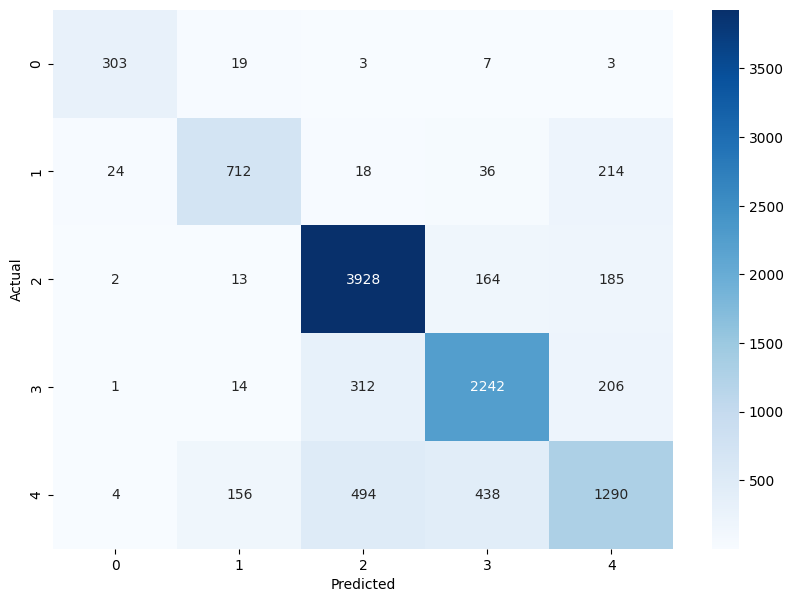

In [23]:
# for random forest
xgb = RandomForestClassifier()
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
print('accuracy_score: ', accuracy_score(y_test, y_pred))
print('confusion_matrix: \n', confusion_matrix(y_test, y_pred))
print('precision_score: ', precision_score(y_test, y_pred, average='macro'))
print('recall_score: ', recall_score(y_test, y_pred, average='macro'))
print('f1_score: ', f1_score(y_test, y_pred, average='macro'))
print("classification_report: \n", classification_report(y_test, y_pred))

plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

accuracy_score:  0.8056173526140156
confusion_matrix: 
 [[ 303   19    3    6    4]
 [  23  714   14   20  233]
 [   1   11 3948  164  168]
 [   1    7  300 2274  193]
 [   3  137  501  289 1452]]
precision_score:  0.816426037421739
recall_score:  0.7929030247334078
f1_score:  0.8028675486282099
classification_report: 
               precision    recall  f1-score   support

           0       0.92      0.90      0.91       335
           1       0.80      0.71      0.75      1004
           2       0.83      0.92      0.87      4292
           3       0.83      0.82      0.82      2775
           4       0.71      0.61      0.66      2382

    accuracy                           0.81     10788
   macro avg       0.82      0.79      0.80     10788
weighted avg       0.80      0.81      0.80     10788



Text(95.72222222222221, 0.5, 'Actual')

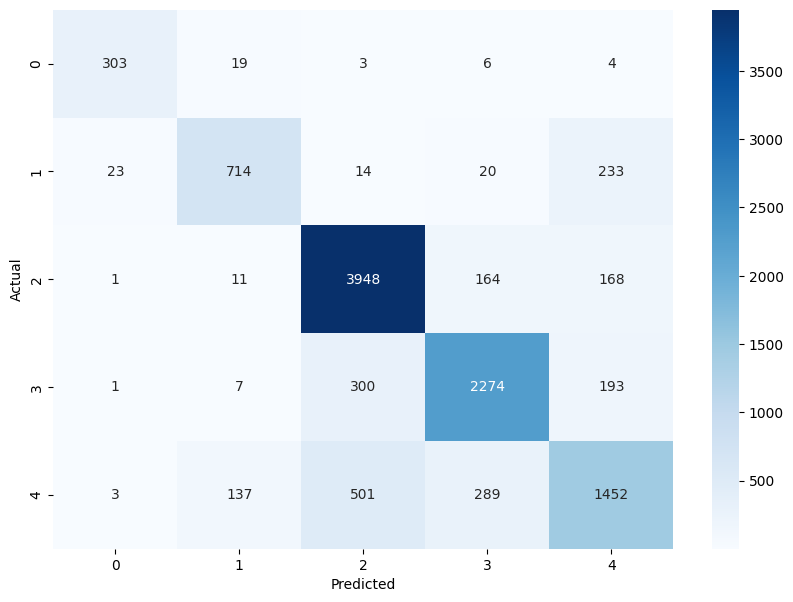

In [22]:

xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
print('accuracy_score: ', accuracy_score(y_test, y_pred))
print('confusion_matrix: \n', confusion_matrix(y_test, y_pred))
print('precision_score: ', precision_score(y_test, y_pred, average='macro'))
print('recall_score: ', recall_score(y_test, y_pred, average='macro'))
print('f1_score: ', f1_score(y_test, y_pred, average='macro'))
print("classification_report: \n", classification_report(y_test, y_pred))

plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

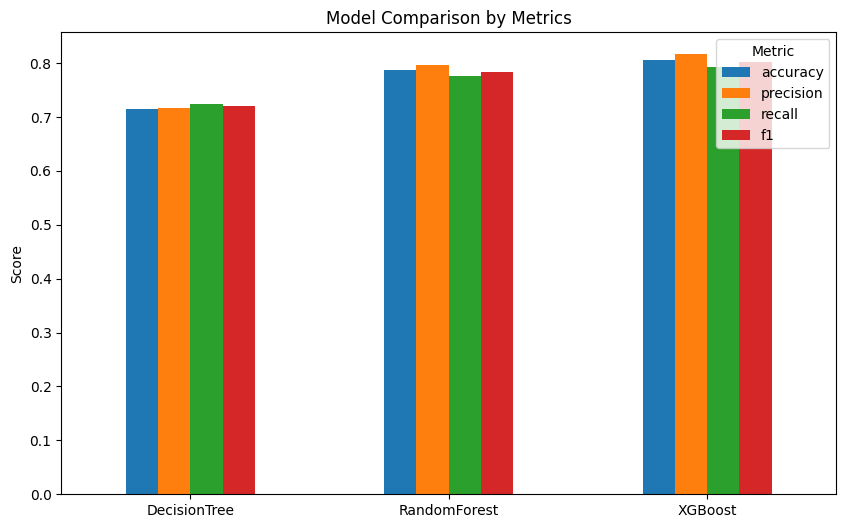

In [24]:
# Collect metrics for each model
metrics = {
    'DecisionTree': {
        'accuracy': accuracy_score(y_test, dt.predict(X_test)),
        'precision': precision_score(y_test, dt.predict(X_test), average='macro'),
        'recall': recall_score(y_test, dt.predict(X_test), average='macro'),
        'f1': f1_score(y_test, dt.predict(X_test), average='macro')
    },
    'RandomForest': {
        'accuracy': accuracy_score(y_test, RandomForestClassifier().fit(X_train, y_train).predict(X_test)),
        'precision': precision_score(y_test, RandomForestClassifier().fit(X_train, y_train).predict(X_test), average='macro'),
        'recall': recall_score(y_test, RandomForestClassifier().fit(X_train, y_train).predict(X_test), average='macro'),
        'f1': f1_score(y_test, RandomForestClassifier().fit(X_train, y_train).predict(X_test), average='macro')
    },
    'XGBoost': {
        'accuracy': accuracy_score(y_test, XGBClassifier().fit(X_train, y_train).predict(X_test)),
        'precision': precision_score(y_test, XGBClassifier().fit(X_train, y_train).predict(X_test), average='macro'),
        'recall': recall_score(y_test, XGBClassifier().fit(X_train, y_train).predict(X_test), average='macro'),
        'f1': f1_score(y_test, XGBClassifier().fit(X_train, y_train).predict(X_test), average='macro')
    }
}

# Convert to DataFrame for plotting
metrics_df = pd.DataFrame(metrics).T

# Plot
metrics_df.plot(kind='bar', figsize=(10,6))
plt.ylabel('Score')
plt.title('Model Comparison by Metrics')
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.show()